The goal of this is to further annotate the E8.0 cardiac celltype done by the celltypist model trained with Robin+Pijuan data. 

1. We subset the cells to celltypist labeled cells CM, Exe Mesoderm, intermediate mesoderm, mesenchym, paraxial mesoderm, and pharyngeal mesoderm.

2. Regenerate umap and leiden clustering

3. Regenerate marker genes

4. Finding an appropriate leiden clustering and annotate the cluster with appropriate celltype (with Robin)


In [1]:
import scanpy as sc
import treedata as td
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')
from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom
from src.III_celltype_annotation.plot_celltype_annotation import (
    filter_marker_genes,
    get_marker_vmin_vmax,
    plot_marker_genes_feature,
    plot_markers_violin_comparison,
)

In [3]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/celltypist_annotation/Robin_Pijuan/E8_0/Deeper_Cardiac_Annotation"
output_path_plot = base_path+plot_dir+"/celltypist_annotation/Robin_Pijuan/E8_0/Deeper_Cardiac_Annotation"
tdata_file = base_path + data_dir + "/Processed_data/E8_0.h5td"

#### Loading data

In [4]:
tdata = td.read_h5td(tdata_file)

In [5]:
tdata

TreeData object with n_obs × n_vars = 21942 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Robin_celltypist_annotation', 'Robin_Pijuan_celltypist_annotation'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Robin_Pijuan_celltypist_annotation_colors', 'Robin_celltypist_annotation_colors', 'leiden_0.25', 'leiden_0.25_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'leiden_names', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters'
    varm: 'PCs'
    layers: 'Norm_count', 'Raw_count'
    obsp: 'connectivities', 'distances'
    obst: 'E8.0-R3-C2', 'E8.0-R2-C2', 'E8.0-R1-C2', 'E8.0-R1-C3', 'E8.0-R2-C1', 'E8.0-R3-C5', 'E8.0-R3-C1', 'E8.0-R1-C1', 'E8.0-R3-C6', 'E8.0-R3-

In [6]:
# List out the celltype name 
tdata.obs["Robin_Pijuan_celltypist_annotation"].unique().tolist()

['Erythroid3',
 'Surface ectoderm',
 'Rostral neurectoderm',
 'Intermediate mesoderm',
 'Somitic mesoderm',
 'Caudal epiblast',
 'Caudal Mesoderm',
 'Spinal cord',
 'Paraxial mesoderm',
 'Gut',
 'Pharyngeal mesoderm',
 'Def. endoderm',
 'ExE mesoderm',
 'Allantois',
 'Cardiomyocytes',
 'Blood progenitors 2',
 'Haematoendothelial progenitors',
 'Endothelium',
 'Mesenchyme',
 'Notochord',
 'Erythroid2',
 'Caudal neurectoderm',
 'Forebrain/Midbrain/Hindbrain',
 'PGC',
 'ExE endoderm',
 'Erythroid1',
 'Visceral endoderm',
 'Blood progenitors 1',
 'NMP',
 'Parietal endoderm']

In [7]:
# set of celltypes to subset to
celltype_list = {'Intermediate mesoderm','Cardiomyocytes','Paraxial mesoderm','Pharyngeal mesoderm','Mesenchyme','ExE mesoderm',}

In [8]:
tdata_subset = tdata[tdata.obs["Robin_Pijuan_celltypist_annotation"].isin(celltype_list)]

In [9]:
tdata_subset

View of TreeData object with n_obs × n_vars = 6600 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Robin_celltypist_annotation', 'Robin_Pijuan_celltypist_annotation'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Robin_Pijuan_celltypist_annotation_colors', 'Robin_celltypist_annotation_colors', 'leiden_0.25', 'leiden_0.25_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'leiden_names', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters'
    varm: 'PCs'
    layers: 'Norm_count', 'Raw_count'
    obsp: 'connectivities', 'distances'
    obst: 'E8.0-R3-C2', 'E8.0-R2-C2', 'E8.0-R1-C2', 'E8.0-R1-C3', 'E8.0-R2-C1', 'E8.0-R3-C5', 'E8.0-R3-C1', 'E8.0-R1-C1', 'E8.0-R3-C6', 'E

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


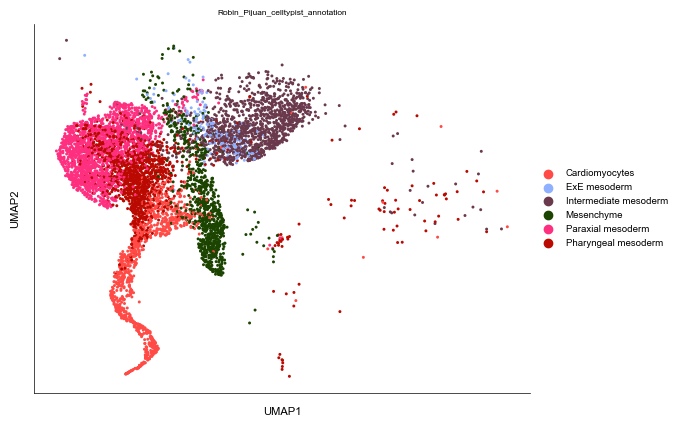

In [10]:
sc.pl.umap(tdata_subset, color = 'Robin_Pijuan_celltypist_annotation')

#### Recalculating pca, umap, and leiden

In [11]:
tdata_subset.X = tdata_subset.layers["Raw_count"] # setting to raw

In [12]:
tdata_subset.X.max()

np.float32(6084.0)

In [13]:
sc.experimental.pp.highly_variable_genes(tdata_subset, n_top_genes=2000)
sc.experimental.pp.normalize_pearson_residuals_pca(tdata_subset)

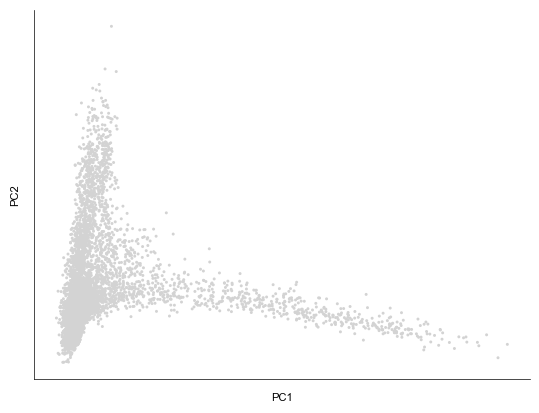

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


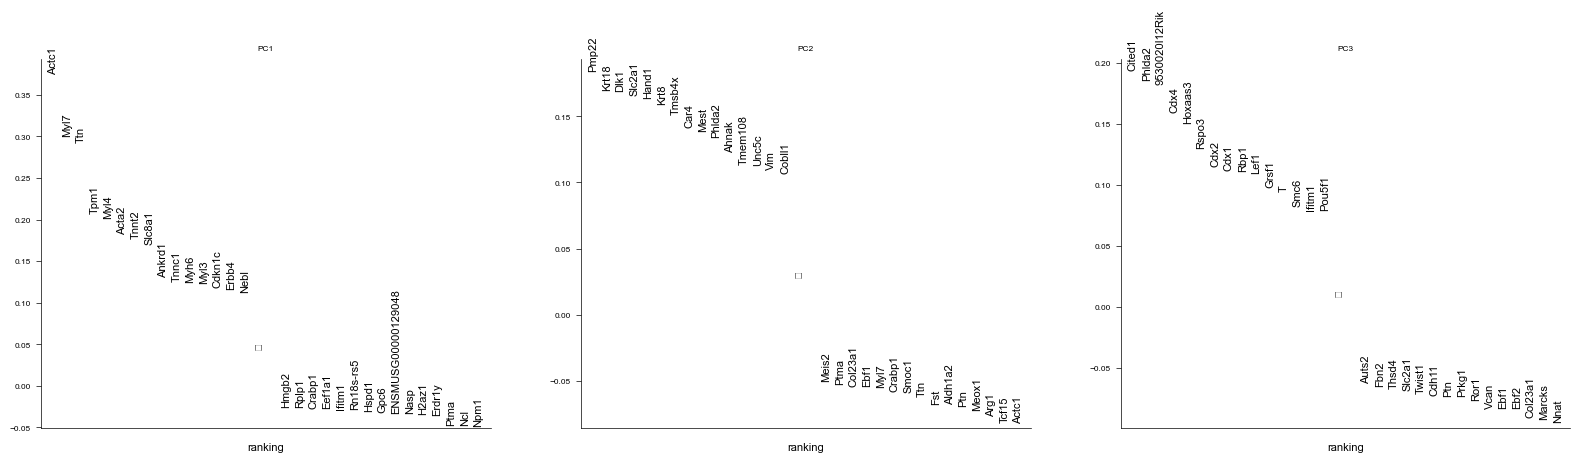

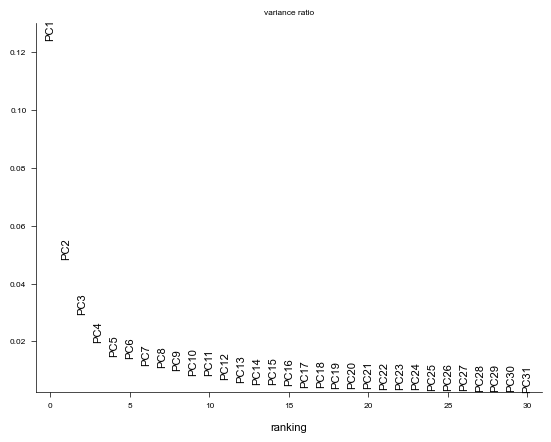

In [14]:
sc.pl.pca_overview(tdata_subset)

In [15]:
sc.pp.neighbors(tdata_subset, n_pcs=10)


/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
sc.tl.umap(tdata_subset)

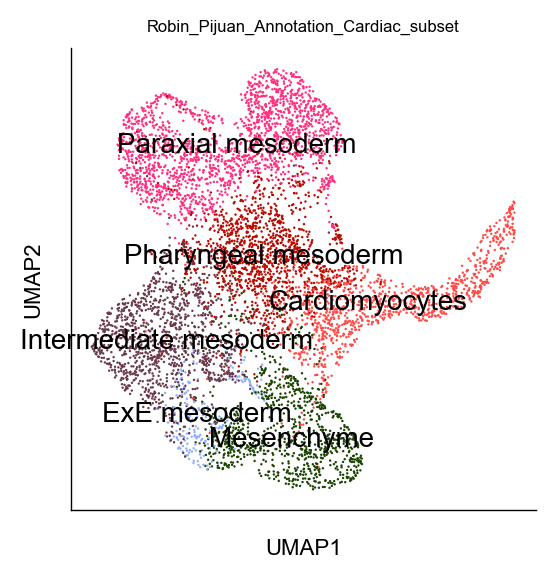

In [17]:
fig, ax = plt.subplots(figsize = (3,3), dpi = 200)
sc.pl.umap(tdata_subset, size=3, ax=ax, color = 'Robin_Pijuan_celltypist_annotation', title = "Robin_Pijuan_Annotation_Cardiac_subset", show = False, legend_loc="on data")
plt.savefig(output_path_plot+"/E8_0_Robin_Pijuan_Annotation_Cardiac_subset.png")

#### Leiden Clustering

In [18]:
from src.II_integration_clustering.plot_integration_clustering import plot_clustering

In [22]:
res_list = [0.25, 0.5, 1.0, 2.0]

leiden_keys = []
for res in res_list:
    key = f"leiden_{res}"
    print(f"clustering for resolution {res}...")
    sc.tl.leiden(
        tdata_subset, resolution=res,
        key_added=key,
        neighbors_key="neighbors",
        flavor="igraph",
        n_iterations=2,
        directed=False
    )
    leiden_keys.append(key)

# build filename-safe names without decimals for saving plots
# e.g. leiden_0.25 -> l025
leiden_names = [
    "l" + key.split("_")[1].replace(".", "")
    for key in leiden_keys
]
tdata_subset.uns["leiden_names"] = leiden_names

plot_clustering(tdata_subset, leiden_keys, output_path_plot, legend_loc="on data", umap_coords_obsm = "X_umap")

clustering for resolution 0.25...
clustering for resolution 0.5...
clustering for resolution 1.0...
clustering for resolution 2.0...


#### Generate the same marker genes

In [20]:
grouped_markers = {
    "Primitive_streak": ["Nanog", "Eomes", "T"],
    "Nascent_mesoderm": ["Mesp2", "Lefty2", "Tdgf1", "Mesp1"],
    "Mixed_mesoderm": ["Phlda2", "Msx1", "Msx2", "Ifitm1"],
    "Paraxial_Pharyngeal_mesoderm": ["Tcf15"],
    "ExE_mesoderm": ["Cdx1", "Cdx2", "Cdx4", "Bmp4"],
    "aSH_Pharyngeal_mesoderm": ["Isl1", "Fgf10", "Tbx1"],
    "pSHF_Pharyngeal_mesoderm": ["Osr1", "Aldh1a2", "Arg1"],
    "Mesenchyme": ["Igf2", "Krt8", "Krt18", "Pmp22", "Ahnak"],
    "JCF_Mesenchyme": ["Hand1", "Foxf1", "Mab21l2"],
    "Cardiomyocytes": ["Ttn", "Tnnt2", "Myl7", "Acta2"],
}

In [21]:
tdata.X = tdata.layers["Norm_count"]
markers_filtered = filter_marker_genes(tdata, grouped_markers)
markers_vmin_vmax = get_marker_vmin_vmax(adata=tdata_subset, markers_filtered=markers_filtered)


plot_marker_genes_feature(
adata=tdata_subset, umap_coords_obsm="X_umap",
markers_filtered=markers_filtered,
output_path_plot=output_path_plot+"/",
markers_vmin_vmax=markers_vmin_vmax)